# **Organização do banco de dados e importação de bibliotecas:**

Esta célula importa as bibliotecas necessárias, adiciona o diretório `src` ao caminho do projeto e carrega funções auxiliares para preparação dos dados, extração de variáveis climáticas, construção do grafo, treinamento e avaliação dos modelos. Também define o dispositivo de execução (`cuda` ou `cpu`) e configura o intervalo temporal usado no experimento, alternando entre modo rápido e modo completo.

In [1]:
import os
import copy
import json
import time
import random
from pathlib import Path
#import yaml
import itertools
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


import sys
sys.path.append("../src")

from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split, create_batchs
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )    
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss

from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "full"  # quick or full
if RUN_MODE == "full":
    start_date = "1980-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date = "2025-06-30"

Esta célula define uma função para extrair uma variável climática de um dataset ERA5 nas coordenadas das estações meteorológicas. A função seleciona o intervalo temporal desejado, localiza o ponto de grade mais próximo de cada estação, organiza as séries no formato `(tempo, estações)` e, quando necessário, agrega dados horários em médias diárias.

In [2]:
def get_var_at_stations(ds: xr.Dataset,
                        var_name: str,
                        t1: str,
                        t2: str,
                        stations: dict) -> np.ndarray:
    """
    Extrai a variável `var_name` de um dataset ERA5 nos pontos das estações.
    Retorna array (T, N) com a série temporal diária para cada estação.
    """
    da = ds[var_name].sel(time=slice(t1, t2))                # Recorta o intervalo temporal desejado
 
    # Detecta os nomes das coordenadas espaciais (ERA5 usa latitude/longitude)
    lat_name = "latitude" if "latitude" in da.dims else "lat"   # Nome do eixo de latitude
    lon_name = "longitude" if "longitude" in da.dims else "lon" # Nome do eixo de longitude
 
    series = []                                              # Lista para acumular séries por estação
    for sid, info in stations.items():                       # Itera sobre cada estação no dicionário
        lat, lon = info["lat"], info["lon"]                  # Coordenadas da estação atual
        s = da.sel({lat_name: lat, lon_name: lon},           # Interpolação por vizinho mais próximo
                   method="nearest").values                  # Converte para NumPy
        series.append(s)                                     # Acumula a série da estação
 
    arr = np.stack(series, axis=1)                           # Empilha → shape (T, N)
 
    # Se a série é horária, agrega para diária (média do dia)
    if len(arr) > (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1:
        # Recria com índice temporal e faz resample diário
        time_index = pd.to_datetime(da["time"].values)       # Índice de tempo do xarray
        df = pd.DataFrame(arr, index=time_index)             # DataFrame para usar resample
        arr = df.resample("D").mean().values                 # Média diária por estação
 
    return arr.astype(np.float32)                            # Retorna como float32

## **Listagem de estações e estação escolhida:**

### Carregamento do catálogo de estações

Esta célula localiza e lê o catálogo do INMET, cria um dicionário com as estações do Rio Grande do Sul e transforma suas chaves em uma lista ordenada. Em seguida, exibe o nome e as coordenadas da estação no índice 32, permitindo conferir a correspondência entre índice, estação e localização geográfica.

In [3]:
catalog_dir = (Path("..") / "Datasets" / "dados_inmet").resolve()

catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)

estacoes = list(estacoes_RS.keys())
print(f"Estação no índice 32: {estacoes[32]}")
print(f"Coordenadas: {estacoes_RS[estacoes[32]]}")

Estação no índice 32: PORTO ALEGRE - JARDIM BOTANICO
Coordenadas: ['-30.05361111', '-51.17472221']


## **Carregamento do banco de dados:**

Esta célula define o diretório base do projeto, aponta para a pasta com os arquivos NetCDF e configura o período de análise. Em seguida, carrega os datasets do ERA5 referentes à precipitação, temperatura e velocidade vertical, já recortados para o intervalo selecionado, além de calcular o número total de dias e de estações consideradas.

In [4]:
base = Path("..").resolve()
nc_dir = os.path.join(base, "Datasets", "nc_files")          # Pasta com os arquivos NetCDF
 
start_date = "2024-01-01"
end_date = "2025-06-30"                         
 
# Carrega os três datasets (precipitação, temperatura, umidade/orvalho)
rea_tp = xr.open_dataset(os.path.join(nc_dir, "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))   # Precipitação
rea_temp  = xr.open_dataset(os.path.join(nc_dir, "temp_05-25.nc")).sel(time=slice(start_date, end_date))     # Temperatura 2m (t2m)
rea_vv = xr.open_dataset(os.path.join(nc_dir, "era5_vv_06-25.nc")).sel(time=slice(start_date, end_date))        # Vertical Velocity
 
T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1   # Total de dias
N = len(estacoes_RS)                                                    # Total de estações

Esta célula transforma os dados brutos do ERA5 em variáveis diárias usadas pelo modelo. A velocidade vertical e a temperatura são agregadas em produtos diários, enquanto a precipitação acumulada é convertida para milímetros e ajustada para manter o alinhamento temporal com as demais séries.

In [5]:
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

# Itera sobre os valores e converte string -> float
coords = np.array([[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
                  dtype=np.float64)
nomes = list(estacoes_RS.keys())   # guarde se quiser saber qual nó é qual estação
N = coords.shape[0]

# **Escolha dos k-vizinhos e criação da matriz de adjacências:**

## Escolha dos k-vizinhos:

A escolha de $k$ define quantos vizinhos mais próximos cada estação considera no grafo. Valores menores deixam o grafo mais local, enquanto valores maiores aumentam a conectividade e a propagação de informação entre estações.

In [6]:
k = 3 # Aqui escolhemos o valor de k.

## Matriz de adjacências via vizinhos:

Esta célula constrói a estrutura espacial do grafo a partir das coordenadas das estações. Para isso, identifica os `k` vizinhos mais próximos de cada estação, monta a matriz de adjacência, torna as conexões simétricas, adiciona self-loops e normaliza cada linha da matriz para que a agregação das features represente uma média entre a estação e seus vizinhos.

In [7]:
nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
_, idx = nbrs.kneighbors(coords)
idx = idx[:, 1:]

# Cria uma matriz N x N preenchida com zeros
A = np.zeros((N, N), dtype=np.float32)

# Para cada nó i, marca como 1 a posição dos seus k vizinhos mais próximos.
# A[i, idx[i]] = 1.0 indica "existe aresta de i para cada vizinho na lista idx[i]".
# Note: nesse passo, A ainda é direcional (i -> j não implica j -> i).
for i in range(N):
    A[i, idx[i]] = 1.0

# Torna a matriz simétrica via "OU" entre A e sua transposta.
# np.maximum(A, A.T) garante que se i é vizinho de j OU j é vizinho de i, a aresta existe nos dois sentidos.
# Isso transforma o grafo k-NN direcionado em um grafo não-direcionado (vizinhança mútua).
A = np.maximum(A, A.T)

# Adiciona self-loops (cada nó conectado a si mesmo) somando a matriz identidade.
# Self-loops fazem com que, na agregação A @ X, cada nó preserve suas próprias features
# junto com as dos vizinhos, em vez de ser substituído apenas pela média da vizinhança.
A = A + np.eye(N, dtype=np.float32)

## Escolha da agregação:

Para cada nó $v_i$:

**Inicialização:**

$$
H_{v_i}^{(0)} = X_{v_i}
$$

**Para $k = 1, 2, \ldots, K$:**

$$
A_{v_i}^{(k)}
=
\operatorname{AGG}^{(k)}
\left\{
H_{v_j}^{(k-1)} : v_j \in \mathcal{N}(v_i)
\right\}
$$

$$
H_{v_i}^{(k)}
=
\operatorname{COMB}^{(k)}
\left\{
H_{v_i}^{(k-1)}, A_{v_i}^{(k)}
\right\}
$$

$$
\hat{y}_{v_i}
=
\left(
W^{(K)} \cdot H_{v_i}^{(K-1)} + b^{(K)}
\right)
$$

Estamos na parte de agregação, ou seja, $A_{v_i}^{(k)}$.

In [8]:
# Agregação:

# Calcula o grau de cada nó (soma das conexões na linha) — quantos vizinhos cada um tem (incluindo self-loop).
# keepdims=True mantém shape (N, 1) para permitir broadcasting na divisão linha a linha.
deg = A.sum(axis=1, keepdims=True)

# Divide cada linha de A pelo grau correspondente, transformando soma em média.
# Resultado: cada linha de A_norm soma 1 — agregação vira "média das features dos vizinhos".
A_norm = torch.tensor(A / deg, dtype=torch.float32) 

## Matriz de adjacências obtida:

In [9]:
import numpy as np
import sympy as sp
from IPython.display import display, Math


print(A_norm)

# Caso A_norm seja um tensor PyTorch
A = A_norm.detach().cpu().numpy()

n = 6  # número de linhas e colunas exibidas
recorte = np.round(A[:n, :n], 3)

latex = (
    rf"A_{{\mathrm{{norm}}}} \in "
    rf"\mathbb{{R}}^{{{A.shape[0]} \times {A.shape[1]}}},"
    rf"\qquad "
    rf"A_{{\mathrm{{norm}}}}[0:{n},0:{n}] = "
    + sp.latex(sp.Matrix(recorte))
)

display(Math(latex)) # Essa é a matriz de adjacências obtida.

tensor([[0.2500, 0.0000, 0.2500,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1429, 0.0000,  ..., 0.0000, 0.1429, 0.0000],
        [0.2000, 0.0000, 0.2000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.2500, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000,  ..., 0.0000, 0.2500, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.2500]])


<IPython.core.display.Math object>

## Normalização clássica (Usado posteriormente para GCN):

In [10]:
def normalize_adjacency_gcn(A):
    """
    Normalização usada em GCN:
    
        A_gcn = D^(-1/2) A D^(-1/2)

    Aqui A deve conter as conexões do grafo.
    A diagonal é preenchida com 1 para garantir self-loops.
    """
    if isinstance(A, np.ndarray):
        A = torch.tensor(A, dtype=torch.float32)
    else:
        A = A.clone().detach().float()

    # Transforma em matriz binária de conexão
    A = (A > 0).float()

    # Garante self-loops
    A.fill_diagonal_(1.0)

    # Grau de cada nó
    degree = A.sum(dim=1)

    # D^(-1/2)
    degree_inv_sqrt = torch.pow(degree, -0.5)

    # Evita infinito caso algum nó tenha grau zero
    degree_inv_sqrt[torch.isinf(degree_inv_sqrt)] = 0.0

    # Matriz diagonal D^(-1/2)
    D_inv_sqrt = torch.diag(degree_inv_sqrt)

    # Normalização simétrica da GCN
    A_gcn = D_inv_sqrt @ A @ D_inv_sqrt

    return A_gcn

A_gcn = normalize_adjacency_gcn(A)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_gcn):
        H = A_gcn @ X
        H = self.linear(H)
        return H

# **Montagem do grafo:**

Essas células são necessárias para rodar o grafo, ele faz a separação dos nós em treino, validação e teste, além de definir uma entrada para que o grafo seja exibido.

Aqui o grafo estará sendo exibido baseado no valor de `k` definido anteriormente. A primeira célula, com `n_idx` define o ID da estação meteorológica.

In [11]:
n_idx = 32

## Split de treino, validação e teste:

In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

target_date = "2024-04-05"

# Proporções do split (por nós)
p_train = 0.70
p_val   = 0.10
p_test  = 0.20  # implícito: 1 - p_train - p_val

# =====================================================
# 2) Monta entrada e target para o dia alvo
# =====================================================
t_idx = (pd.to_datetime(target_date) - pd.to_datetime(start_date)).days

vv_t = X_vv[t_idx, :, 0]
t_t  = X_t [t_idx, :, 0]
X_in = torch.stack([vv_t, t_t], dim=-1).float()   # (N, 2)

y_all = X_tp[t_idx, :, 0].float()                 # (N,)

N = X_in.shape[0]   # nº total de nós

# =====================================================
# 2.1) Split por nós: treino / validação / teste
# =====================================================
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N, generator=g)

n_train = int(round(p_train * N))
n_val   = int(round(p_val   * N))
n_test  = N - n_train - n_val

idx_train = perm[:n_train]
idx_val   = perm[n_train : n_train + n_val]
idx_test  = perm[n_train + n_val:]

def make_mask(indices, N):
    m = torch.zeros(N, dtype=torch.bool)
    m[indices] = True
    return m

mask_train = make_mask(idx_train, N)
mask_val   = make_mask(idx_val,   N)
mask_test  = make_mask(idx_test,  N)

print(f"Total de nós: {N}")
print(f"  Treino: {mask_train.sum().item()}  "
      f"Val: {mask_val.sum().item()}  "
      f"Teste: {mask_test.sum().item()}")

Total de nós: 62
  Treino: 43  Val: 6  Teste: 13


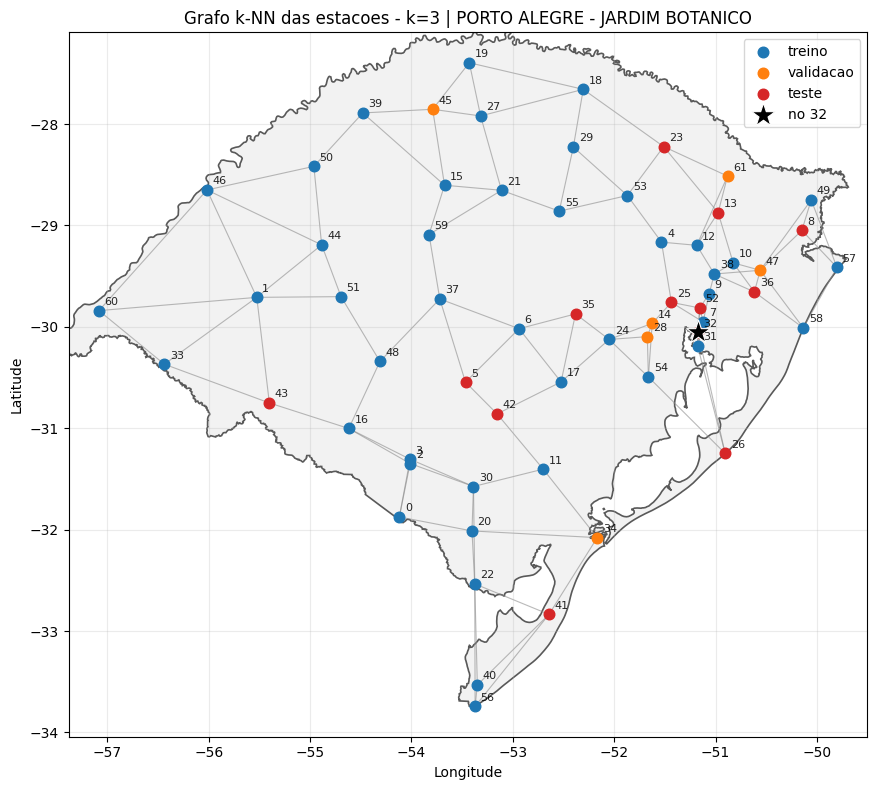

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=3:
  no   7 -> CACHOEIRINHA
  no  26 -> MOSTARDAS
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  52 -> SAPUCAIA DO SUL


In [13]:
import json
import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def carregar_mapa_rs_ibge():
    url = "https://servicodados.ibge.gov.br/api/v3/malhas/estados/43?formato=application/vnd.geo+json"

    req = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/json, application/geo+json",
            "Accept-Encoding": "identity",
        }
    )

    with urllib.request.urlopen(req) as resposta:
        dados = resposta.read()

    # Se vier compactado em gzip, descompacta antes de decodificar
    if dados[:2] == b"\x1f\x8b":
        dados = gzip.decompress(dados)

    return json.loads(dados.decode("utf-8"))


def plot_geojson(ax, geojson, facecolor="#f2f2f2", edgecolor="0.35", linewidth=1.2):
    for feature in geojson["features"]:
        geom = feature["geometry"]

        if geom["type"] == "Polygon":
            polygons = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            polygons = geom["coordinates"]
        else:
            continue

        for polygon in polygons:
            exterior = polygon[0]
            lons = [p[0] for p in exterior]
            lats = [p[1] for p in exterior]

            ax.fill(
                lons,
                lats,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                zorder=0
            )


def build_adjacency(coords, k=2, include_self=False):
    coords = np.asarray(coords, dtype=float)
    N = coords.shape[0]

    if k >= N:
        raise ValueError(f"k={k} precisa ser menor que o numero de nos N={N}.")

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, idx = nbrs.kneighbors(coords)
    idx = idx[:, 1:]

    A_bin = np.zeros((N, N), dtype=bool)

    for i in range(N):
        A_bin[i, idx[i]] = True

    A_bin = A_bin | A_bin.T

    if include_self:
        np.fill_diagonal(A_bin, True)
    else:
        np.fill_diagonal(A_bin, False)

    return A_bin


def as_numpy_mask(mask):
    if hasattr(mask, "detach"):
        return mask.detach().cpu().numpy().astype(bool)
    return np.asarray(mask, dtype=bool)


def plot_knn_graph(coords, k=2, n_idx=32, nomes=None,
                   mask_train=None, mask_val=None, mask_test=None,
                   figsize=(11, 8), label_nodes=True,
                   mapa_rs=None):

    coords = np.asarray(coords, dtype=float)
    A_bin = build_adjacency(coords, k=k, include_self=False)
    N = coords.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    if mapa_rs is not None:
        plot_geojson(ax, mapa_rs)

    for i in range(N):
        for j in range(i + 1, N):
            if A_bin[i, j]:
                ax.plot(
                    [coords[i, 1], coords[j, 1]],
                    [coords[i, 0], coords[j, 0]],
                    color="0.55",
                    linewidth=0.8,
                    alpha=0.6,
                    zorder=1,
                )

    if mask_train is not None and mask_val is not None and mask_test is not None:
        train = as_numpy_mask(mask_train)
        val = as_numpy_mask(mask_val)
        test = as_numpy_mask(mask_test)

        ax.scatter(coords[train, 1], coords[train, 0], s=58, c="tab:blue", label="treino", zorder=3)
        ax.scatter(coords[val, 1], coords[val, 0], s=58, c="tab:orange", label="validacao", zorder=3)
        ax.scatter(coords[test, 1], coords[test, 0], s=58, c="tab:red", label="teste", zorder=3)
    else:
        ax.scatter(coords[:, 1], coords[:, 0], s=58, c="tab:blue", label="estacoes", zorder=3)

    ax.scatter(
        coords[n_idx, 1],
        coords[n_idx, 0],
        s=320,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        label=f"no {n_idx}",
        zorder=5,
    )

    if label_nodes:
        for i in range(N):
            ax.annotate(
                str(i),
                (coords[i, 1], coords[i, 0]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.85,
                zorder=6,
            )

    vizinhos = np.where(A_bin[n_idx])[0]
    nome_no = nomes[n_idx] if nomes is not None else f"no {n_idx}"

    lon = coords[:, 1]
    lat = coords[:, 0]

    ax.set_xlim(lon.min() - 0.3, lon.max() + 0.3)
    ax.set_ylim(lat.min() - 0.3, lat.max() + 0.3)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"Grafo k-NN das estacoes - k={k} | {nome_no}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    print(f"Vizinhos diretos do no {n_idx} ({nome_no}) para k={k}:")
    for j in vizinhos:
        nome_vizinho = nomes[j] if nomes is not None else f"no {j}"
        print(f"  no {j:3d} -> {nome_vizinho}")

    return A_bin


mapa_rs = carregar_mapa_rs_ibge()

A_grafo2 = plot_knn_graph(coords, k=k, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)


# **Modelos:**

## Definição dos hiperparâmetros:

In [14]:
F_in  = 2 # F_in é a dimensão das features de entrada. Como estamos tratando 
          # de umidade e velocidade vertical, a dimensão é 2.
hidden = 2 # Número de neurônios na camada oculta
lr = 1e-3 # Taxa de aprendizado "eta".
n_hidden_layers = 6 # Número de camadas ocultas.
patience = 50 # Paciência.
min_delta = 1e-5 # Critério de parada.


## **Funções para a GNN simples:**

In [15]:
# Modelo: GNN simples com quantidade variavel de camadas ocultas

class SimpleGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_hidden_layers=n_hidden_layers, out_dim=1):
        super().__init__()

        self.hidden_layers = nn.ModuleList()

        # Primeira camada oculta: entrada -> hidden
        self.hidden_layers.append(
            nn.Linear(in_dim, hidden_dim)
        )

        # Demais camadas ocultas: hidden -> hidden
        for _ in range(n_hidden_layers - 1):
            self.hidden_layers.append(
                nn.Linear(hidden_dim, hidden_dim)
            )

        self.W_out = nn.Linear(hidden_dim, out_dim)

    def forward(self, X, A_norm):
        H = X

        for layer in self.hidden_layers:
            H = A_norm @ H
            H = F.relu(layer(H))

        out = self.W_out(H)
        return out.squeeze(-1)


modelo = SimpleGNN(
    in_dim=F_in,
    hidden_dim=hidden,
    n_hidden_layers=n_hidden_layers
)

otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
loss_fn = nn.MSELoss()

## **Funções para a GCN simples:**

In [16]:
# Modelo: GCN simples com quantidade variavel de camadas ocultas

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_gcn):
        H = A_gcn @ X
        H = self.linear(H)
        return H


class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_hidden_layers=n_hidden_layers, out_dim=1, dropout=0.0):
        super().__init__()

        self.hidden_layers = nn.ModuleList()
        self.dropout = dropout

        # Primeira camada oculta: entrada -> hidden
        self.hidden_layers.append(
            GCNLayer(in_dim, hidden_dim)
        )

        # Demais camadas ocultas: hidden -> hidden
        for _ in range(n_hidden_layers - 1):
            self.hidden_layers.append(
                GCNLayer(hidden_dim, hidden_dim)
            )

        # Camada de saida: hidden -> out
        self.output_layer = GCNLayer(hidden_dim, out_dim)

    def forward(self, X, A_gcn):
        H = X

        for layer in self.hidden_layers:
            H = layer(H, A_gcn)
            H = F.relu(H)
            H = F.dropout(H, p=self.dropout, training=self.training)

        out = self.output_layer(H, A_gcn)

        return out.squeeze(-1)


modelo = GCN(
    in_dim=F_in,
    hidden_dim=hidden,
    n_hidden_layers=n_hidden_layers,
    out_dim=1,
    dropout=0.0
)

otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
loss_fn = nn.MSELoss()

## **Rodagem dos experimentos:**

In [17]:
import copy
import itertools
import pandas as pd
import matplotlib.pyplot as plt

import copy

def run_experiment(
    epochs,
    hidden,
    n_hidden_layers,
    X_in,
    y_all,
    A_norm,
    mask_train,
    mask_val,
    mask_test,
    F_in=F_in,
    lr=lr,
    n_idx=n_idx,
    seed=SEED,
    patience=patience,
    min_delta=min_delta
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    modelo = SimpleGNN(
        in_dim=F_in,
        hidden_dim=hidden,
        n_hidden_layers=n_hidden_layers,
        out_dim=1
    )

    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    historico = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
    }

    best_val = float("inf")
    best_epoch = 0
    stop_epoch = epochs
    patience_count = 0
    best_state = copy.deepcopy(modelo.state_dict())

    for epoca in range(epochs + 1):
        modelo.train()
        otimizador.zero_grad()

        y_pred_all = modelo(X_in, A_norm)

        loss_train = loss_fn(
            y_pred_all[mask_train],
            y_all[mask_train]
        )

        loss_train.backward()
        otimizador.step()

        modelo.eval()
        with torch.no_grad():
            y_pred_eval = modelo(X_in, A_norm)

            loss_val = loss_fn(
                y_pred_eval[mask_val],
                y_all[mask_val]
            )

            loss_test = loss_fn(
                y_pred_eval[mask_test],
                y_all[mask_test]
            )

        historico["train_loss"].append(loss_train.item())
        historico["val_loss"].append(loss_val.item())
        historico["test_loss"].append(loss_test.item())

        if loss_val.item() < best_val - min_delta:
            best_val = loss_val.item()
            best_epoch = epoca
            best_state = copy.deepcopy(modelo.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            stop_epoch = epoca
            break

            modelo.load_state_dict(best_state)

    modelo.eval()
    with torch.no_grad():
        y_pred_all = modelo(X_in, A_norm)

        loss_train_f = loss_fn(
            y_pred_all[mask_train],
            y_all[mask_train]
        ).item()

        loss_val_f = loss_fn(
            y_pred_all[mask_val],
            y_all[mask_val]
        ).item()

        loss_test_f = loss_fn(
            y_pred_all[mask_test],
            y_all[mask_test]
        ).item()

        mae_train = (y_pred_all[mask_train] - y_all[mask_train]).abs().mean().item()
        mae_val   = (y_pred_all[mask_val]   - y_all[mask_val]).abs().mean().item()
        mae_test  = (y_pred_all[mask_test]  - y_all[mask_test]).abs().mean().item()

        pred_no = y_pred_all[n_idx].item()
        true_no = y_all[n_idx].item()

    return {
        "epochs": epochs,
        "hidden": hidden,
        "n_hidden_layers": n_hidden_layers,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "loss_train": loss_train_f,
        "loss_val": loss_val_f,
        "loss_test": loss_test_f,
        "mae_train": mae_train,
        "mae_val": mae_val,
        "mae_test": mae_test,
        "pred": pred_no,
        "true": true_no,
        "historico": historico,
        
    }

def run_experiment_gcn(
    epochs,
    hidden,
    n_hidden_layers,
    X_in,
    y_all,
    A_gcn,
    mask_train,
    mask_val,
    mask_test,
    F_in=F_in,
    lr=lr,
    n_idx=n_idx,
    seed=SEED,
    patience=patience,
    min_delta=min_delta,
    dropout=0.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    modelo = GCN(
        in_dim=F_in,
        hidden_dim=hidden,
        n_hidden_layers=n_hidden_layers,
        out_dim=1,
        dropout=dropout
    )

    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    historico = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
    }

    best_val = float("inf")
    best_epoch = 0
    stop_epoch = epochs
    patience_count = 0
    best_state = copy.deepcopy(modelo.state_dict())

    for epoca in range(epochs + 1):
        modelo.train()
        otimizador.zero_grad()

        y_pred_all = modelo(X_in, A_gcn)
        loss_train = loss_fn(y_pred_all[mask_train], y_all[mask_train])

        loss_train.backward()
        otimizador.step()

        modelo.eval()
        with torch.no_grad():
            y_pred_eval = modelo(X_in, A_gcn)

            loss_val = loss_fn(y_pred_eval[mask_val], y_all[mask_val])
            loss_test = loss_fn(y_pred_eval[mask_test], y_all[mask_test])

        historico["train_loss"].append(loss_train.item())
        historico["val_loss"].append(loss_val.item())
        historico["test_loss"].append(loss_test.item())

        if loss_val.item() < best_val - min_delta:
            best_val = loss_val.item()
            best_epoch = epoca
            best_state = copy.deepcopy(modelo.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            stop_epoch = epoca
            break

    modelo.load_state_dict(best_state)

    modelo.eval()
    with torch.no_grad():
        y_pred_all = modelo(X_in, A_gcn)

        loss_train_f = loss_fn(y_pred_all[mask_train], y_all[mask_train]).item()
        loss_val_f   = loss_fn(y_pred_all[mask_val],   y_all[mask_val]).item()
        loss_test_f  = loss_fn(y_pred_all[mask_test],  y_all[mask_test]).item()

        mae = lambda a, b: (a - b).abs().mean().item()

        mae_train = mae(y_pred_all[mask_train], y_all[mask_train])
        mae_val   = mae(y_pred_all[mask_val],   y_all[mask_val])
        mae_test  = mae(y_pred_all[mask_test],  y_all[mask_test])

        pred_no = y_pred_all[n_idx].item()
        true_no = y_all[n_idx].item()

    return {
        "epochs": epochs,
        "hidden": hidden,
        "n_hidden_layers": n_hidden_layers,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "loss_train": loss_train_f,
        "loss_val": loss_val_f,
        "loss_test": loss_test_f,
        "mae_train": mae_train,
        "mae_val": mae_val,
        "mae_test": mae_test,
        "pred": pred_no,
        "true": true_no,
        "historico": historico,
    }

## Rodagem para diversos valores de épocas e neurônios nas camadas ocultas (GNN):

Essa célula é responsável para a rodagem do modelo para diversos valores de épocas e de neurônios nas camadas ocultas.

In [18]:
epochs_grid = [200, 400, 600, 1500]
hidden_grid = [2, 6, 12]

In [19]:
resultados = []
historicos = {}
paradas = {}

for ep, hd in itertools.product(epochs_grid, hidden_grid):
    print(f"Rodando epochs={ep}, hidden={hd}, hidden_layers={n_hidden_layers}...")

    r = run_experiment(
        epochs=ep,
        hidden=hd,
        n_hidden_layers=n_hidden_layers,
        X_in=X_in,
        y_all=y_all,
        A_norm=A_norm,
        mask_train=mask_train,
        mask_val=mask_val,
        mask_test=mask_test,
        F_in=F_in,
        lr=lr,
        n_idx=n_idx,
        seed=SEED,
        patience=patience,
        min_delta=min_delta
    )

    historicos[(ep, hd)] = r["historico"]
    paradas[(ep, hd)] = r["stop_epoch"]

    r_sem_historico = r.copy()
    del r_sem_historico["historico"]

    resultados.append(r_sem_historico)

df = pd.DataFrame(resultados)
print(df)

Rodando epochs=200, hidden=2, hidden_layers=6...
Rodando epochs=200, hidden=6, hidden_layers=6...
Rodando epochs=200, hidden=12, hidden_layers=6...
Rodando epochs=400, hidden=2, hidden_layers=6...
Rodando epochs=400, hidden=6, hidden_layers=6...
Rodando epochs=400, hidden=12, hidden_layers=6...
Rodando epochs=600, hidden=2, hidden_layers=6...
Rodando epochs=600, hidden=6, hidden_layers=6...
Rodando epochs=600, hidden=12, hidden_layers=6...
Rodando epochs=1500, hidden=2, hidden_layers=6...
Rodando epochs=1500, hidden=6, hidden_layers=6...
Rodando epochs=1500, hidden=12, hidden_layers=6...
    epochs  hidden  n_hidden_layers  best_epoch  stop_epoch  loss_train  \
0      200       2                6         200         200   23.162546   
1      200       6                6         200         200   21.065592   
2      200      12                6          97         147   19.469969   
3      400       2                6         400         400   20.109852   
4      400       6            

## Criação dos gráficos de perda de treino e teste (GNN):

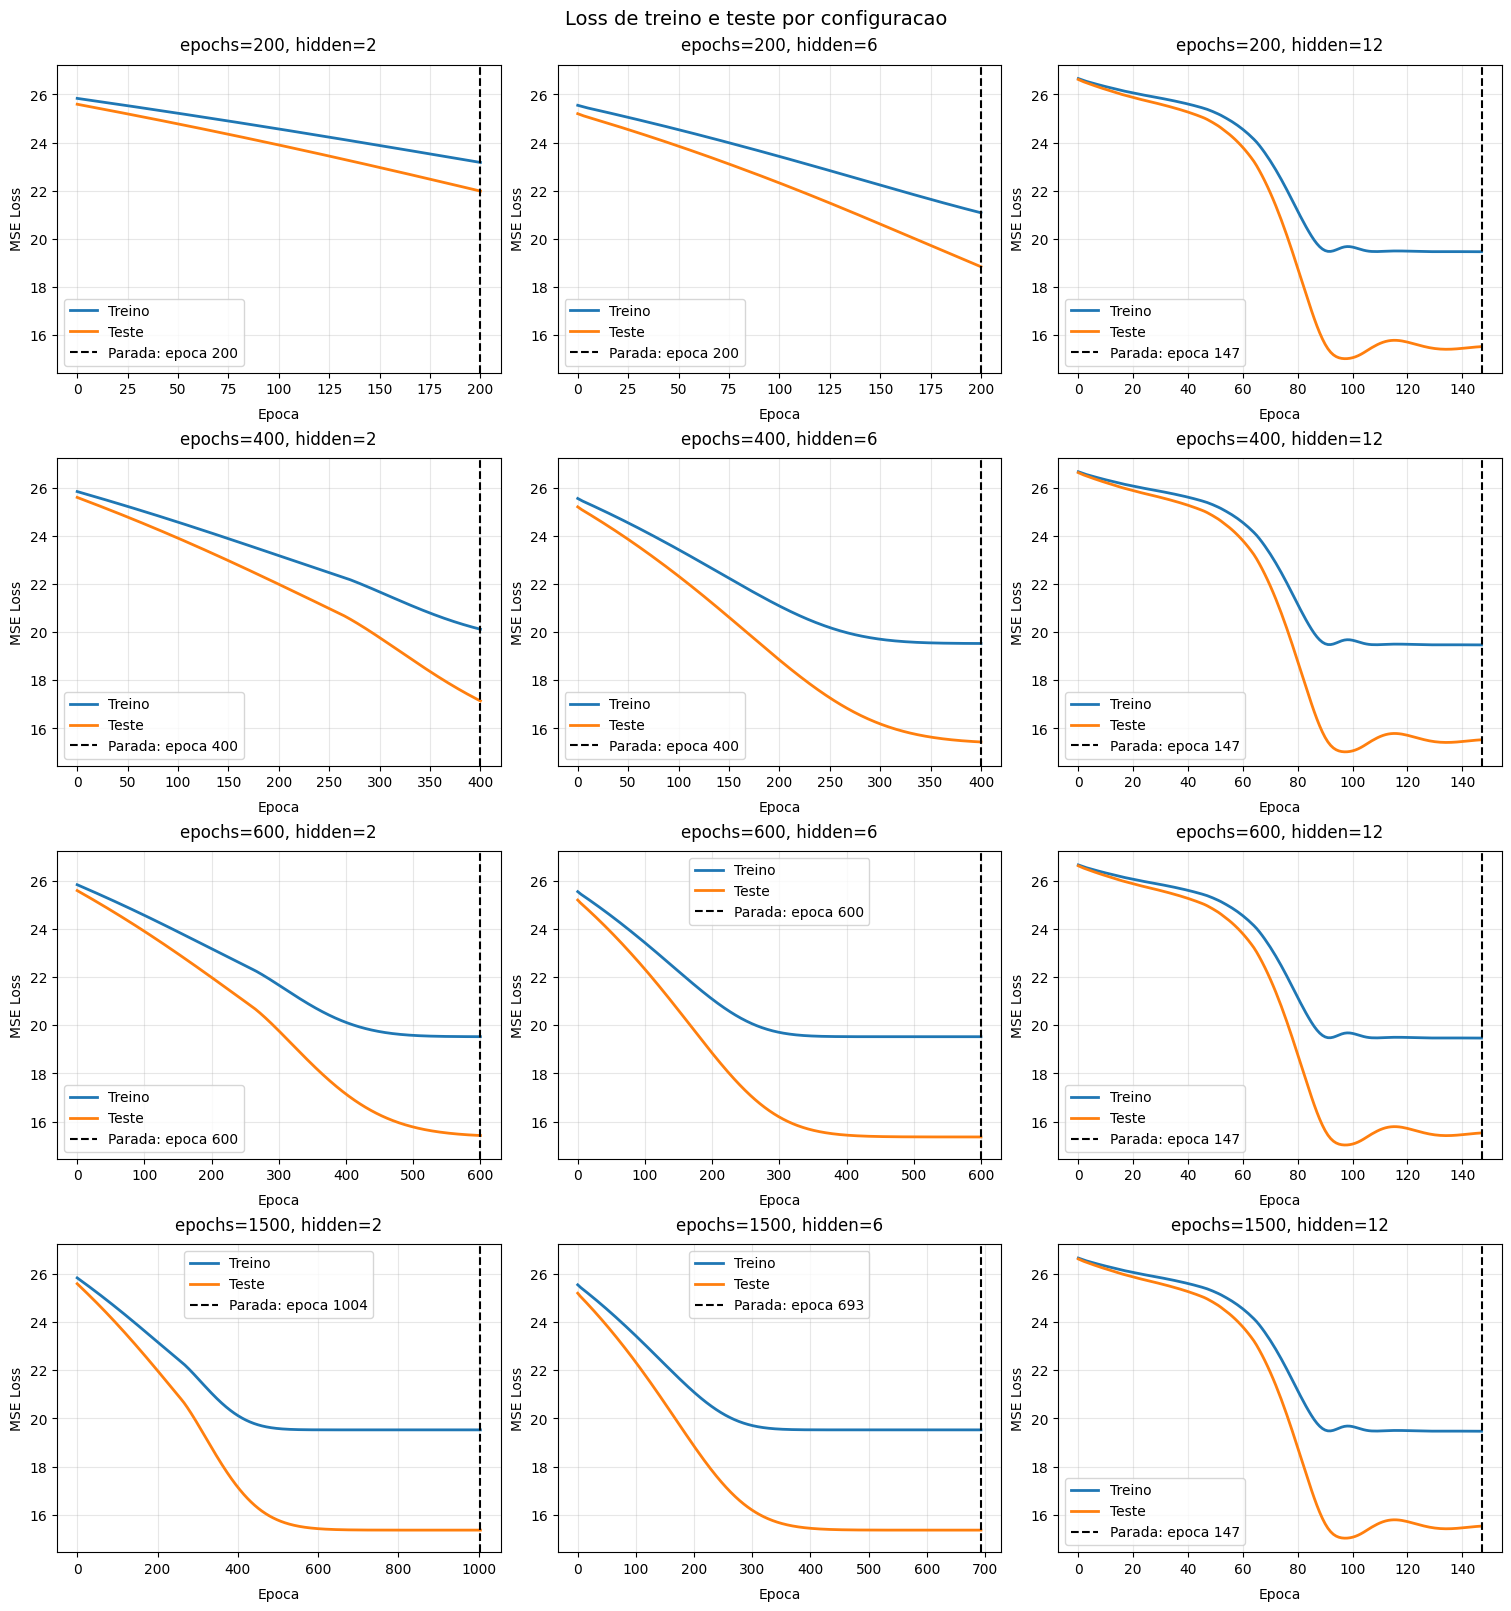

In [20]:
from pathlib import Path

n_linhas = len(epochs_grid)
n_colunas = len(hidden_grid)

todos_losses = []

for ep in epochs_grid:
    for hd in hidden_grid:
        hist = historicos[(ep, hd)]
        todos_losses.extend(hist["train_loss"])
        todos_losses.extend(hist["test_loss"])

y_min = min(todos_losses)
y_max = max(todos_losses)

margem = 0.05 * (y_max - y_min)

if margem == 0:
    margem = 1

y_min -= margem
y_max += margem

fig, axes = plt.subplots(
    n_linhas,
    n_colunas,
    figsize=(5 * n_colunas, 4 * n_linhas),
    sharey=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(n_linhas, n_colunas)

for i, ep in enumerate(epochs_grid):
    for j, hd in enumerate(hidden_grid):
        ax = axes[i, j]

        hist = historicos[(ep, hd)]
        epocas = range(len(hist["train_loss"]))

        ax.plot(
            epocas,
            hist["train_loss"],
            label="Treino",
            color="tab:blue",
            linewidth=2
        )

        ax.plot(
            epocas,
            hist["test_loss"],
            label="Teste",
            color="tab:orange",
            linewidth=2
        )

        stop_epoch = paradas[(ep, hd)]

        ax.axvline(
            stop_epoch,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Parada: epoca {stop_epoch}"
        )

        ax.set_title(f"epochs={ep}, hidden={hd}", pad=10)
        ax.set_xlabel("Epoca", labelpad=8)
        ax.set_ylabel("MSE Loss")
        ax.set_ylim(y_min, y_max)

        ax.tick_params(axis="y", labelleft=True)

        ax.grid(alpha=0.3)
        ax.legend(loc="best")

fig.suptitle("Loss de treino e teste por configuracao", fontsize=14)
plt.show()

## Rodagem para diversos valores de épocas e neurônios nas camadas ocultas (GCN):

In [21]:
resultados = []
historicos = {}
paradas = {}

for ep, hd in itertools.product(epochs_grid, hidden_grid):
    print(f"Rodando epochs={ep}, hidden={hd}, hidden_layers={n_hidden_layers}...")

    r = run_experiment_gcn(
        epochs=ep,
        hidden=hd,
        n_hidden_layers=n_hidden_layers,
        X_in=X_in,
        y_all=y_all,
        A_gcn=A_gcn,
        mask_train=mask_train,
        mask_val=mask_val,
        mask_test=mask_test,
        F_in=F_in,
        lr=lr,
        n_idx=n_idx,
        seed=SEED,
        patience=patience,
        min_delta=min_delta,
        dropout=0.0,
    )

    historicos[(ep, hd)] = r["historico"]
    paradas[(ep, hd)] = r["stop_epoch"]

    r_sem_historico = r.copy()
    del r_sem_historico["historico"]

    resultados.append(r_sem_historico)

df = pd.DataFrame(resultados)
print(df)

Rodando epochs=200, hidden=2, hidden_layers=6...
Rodando epochs=200, hidden=6, hidden_layers=6...
Rodando epochs=200, hidden=12, hidden_layers=6...
Rodando epochs=400, hidden=2, hidden_layers=6...
Rodando epochs=400, hidden=6, hidden_layers=6...
Rodando epochs=400, hidden=12, hidden_layers=6...
Rodando epochs=600, hidden=2, hidden_layers=6...
Rodando epochs=600, hidden=6, hidden_layers=6...
Rodando epochs=600, hidden=12, hidden_layers=6...
Rodando epochs=1500, hidden=2, hidden_layers=6...
Rodando epochs=1500, hidden=6, hidden_layers=6...
Rodando epochs=1500, hidden=12, hidden_layers=6...
    epochs  hidden  n_hidden_layers  best_epoch  stop_epoch  loss_train  \
0      200       2                6         200         200   23.240194   
1      200       6                6         200         200   21.200037   
2      200      12                6          87         137   20.005835   
3      400       2                6         400         400   20.167234   
4      400       6            

## Criação dos gráficos de perda de treino e teste (GCN):

Grafico salvo em: ..\Graphics\GCNGraphics-K3-HL6-D20240405.png


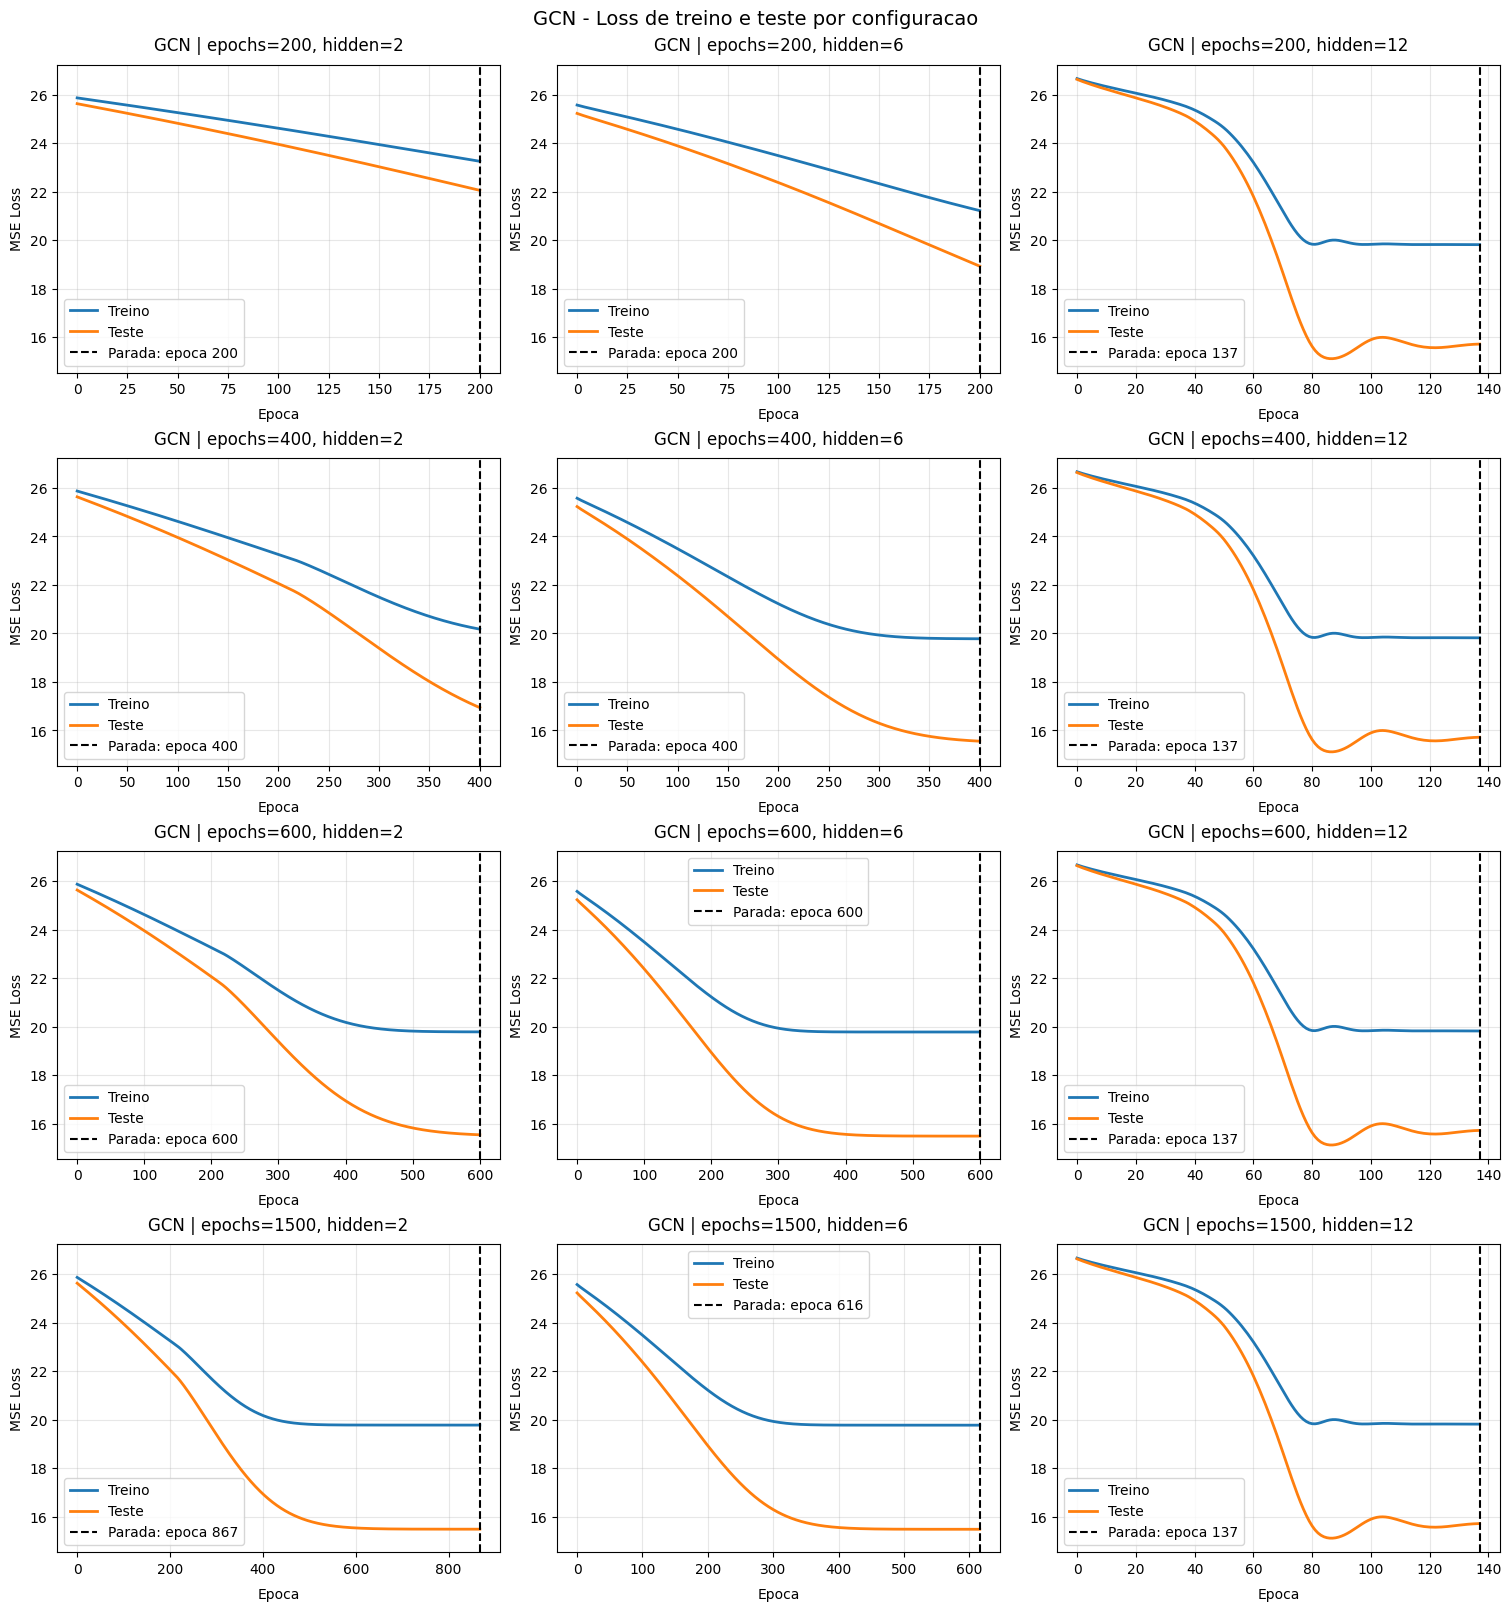

In [22]:
from pathlib import Path

# =====================================================
# Graficos GCN: loss de treino e teste
# =====================================================

n_linhas = len(epochs_grid)
n_colunas = len(hidden_grid)

todos_losses = []

for ep in epochs_grid:
    for hd in hidden_grid:
        hist = historicos[(ep, hd)]
        todos_losses.extend(hist["train_loss"])
        todos_losses.extend(hist["test_loss"])

y_min = min(todos_losses)
y_max = max(todos_losses)

margem = 0.05 * (y_max - y_min)

if margem == 0:
    margem = 1

y_min -= margem
y_max += margem

fig, axes = plt.subplots(
    n_linhas,
    n_colunas,
    figsize=(5 * n_colunas, 4 * n_linhas),
    sharey=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(n_linhas, n_colunas)

for i, ep in enumerate(epochs_grid):
    for j, hd in enumerate(hidden_grid):
        ax = axes[i, j]

        hist = historicos[(ep, hd)]
        epocas = range(len(hist["train_loss"]))

        ax.plot(
            epocas,
            hist["train_loss"],
            label="Treino",
            color="tab:blue",
            linewidth=2
        )

        ax.plot(
            epocas,
            hist["test_loss"],
            label="Teste",
            color="tab:orange",
            linewidth=2
        )

        stop_epoch = paradas[(ep, hd)]

        ax.axvline(
            stop_epoch,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Parada: epoca {stop_epoch}"
        )

        ax.set_title(f"GCN | epochs={ep}, hidden={hd}", pad=10)
        ax.set_xlabel("Epoca", labelpad=8)
        ax.set_ylabel("MSE Loss")
        ax.set_ylim(y_min, y_max)

        ax.tick_params(axis="y", labelleft=True)

        ax.grid(alpha=0.3)
        ax.legend(loc="best")

fig.suptitle("GCN - Loss de treino e teste por configuracao", fontsize=14)

# =====================================================
# Salvar imagem
# =====================================================

graphics_dir = Path("../Graphics")
graphics_dir.mkdir(parents=True, exist_ok=True)

target_date_file = target_date.replace("-", "")

nome_imagem = f"GCNGraphics-K{k}-HL{n_hidden_layers}-D{target_date_file}.png"
output_path = graphics_dir / nome_imagem

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Grafico salvo em: {output_path}")

plt.show()

In [23]:
def build_graph(k, coords, N):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, idx = nbrs.kneighbors(coords)
    idx = idx[:, 1:]

    A = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        A[i, idx[i]] = 1.0

    A = np.maximum(A, A.T)
    A = A + np.eye(N, dtype=np.float32)

    deg = A.sum(axis=1, keepdims=True)
    A_norm = torch.tensor(A / deg, dtype=torch.float32)

    A_gcn = normalize_adjacency_gcn(A)

    return A_norm, A_gcn

def build_day_data(target_date):
    t_idx = (pd.to_datetime(target_date) - pd.to_datetime(start_date)).days

    vv_t = X_vv[t_idx, :, 0]
    t_t  = X_t[t_idx, :, 0]

    X_in = torch.stack([vv_t, t_t], dim=-1).float()
    y_all = X_tp[t_idx, :, 0].float()

    return X_in, y_all

# **Geração de tabelas:**

Essa parte do código corresponde a uma geração de tabelas de perda envolvendo os nós de teste e validação. Os parâmetros são reajustados e os modelos são rodados novamente.

In [24]:
epochs = 200
hidden = 24
n_hidden_layers = 6
k = 3


def gerar_tabela_por_modelo_e_dia(
    modelo_nome,
    data,
    epochs=epochs,
    hidden=hidden,
    n_hidden_layers=n_hidden_layers,
    k=k,
    lr=1e-3,
    patience=60,
    min_delta=1e-4,
    seed=42,
):
    # =====================================================
    # 1) Dados do dia e matrizes do grafo
    # =====================================================
    X_dia, y_dia = build_day_data(data)
    N = X_dia.shape[0]

    A_norm_dia, A_gcn_dia = build_graph(
        k,
        coords,
        N,
    )

    # =====================================================
    # 2) Reprodutibilidade
    # =====================================================
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # =====================================================
    # 3) Escolha do modelo
    # =====================================================
    if modelo_nome == "GNN":
        modelo_dia = SimpleGNN(
            in_dim=F_in,
            hidden_dim=hidden,
            n_hidden_layers=n_hidden_layers,
            out_dim=1,
        )

        matriz_grafo = A_norm_dia

    elif modelo_nome == "GCN":
        modelo_dia = GCN(
            in_dim=F_in,
            hidden_dim=hidden,
            n_hidden_layers=n_hidden_layers,
            out_dim=1,
            dropout=0.0,
        )

        matriz_grafo = A_gcn_dia

    else:
        raise ValueError(
            "modelo_nome deve ser 'GNN' ou 'GCN'."
        )

    # =====================================================
    # 4) Otimizador e função de loss
    # =====================================================
    otimizador_dia = torch.optim.Adam(
        modelo_dia.parameters(),
        lr=lr,
    )

    # reduction="mean": calcula a média dos erros quadráticos
    loss_fn_dia = nn.MSELoss(reduction="mean")

    melhor_loss_validacao = float("inf")
    melhor_estado = copy.deepcopy(
        modelo_dia.state_dict()
    )

    contador_paciencia = 0
    melhor_epoca = 0

    # =====================================================
    # 5) Treinamento
    # =====================================================
    for epoca in range(epochs + 1):
        modelo_dia.train()
        otimizador_dia.zero_grad()

        y_pred_treino = modelo_dia(
            X_dia,
            matriz_grafo,
        )

        loss_treino = loss_fn_dia(
            y_pred_treino[mask_train],
            y_dia[mask_train],
        )

        loss_treino.backward()
        otimizador_dia.step()

        # Validação
        modelo_dia.eval()

        with torch.no_grad():
            y_pred_validacao = modelo_dia(
                X_dia,
                matriz_grafo,
            )

            loss_validacao = loss_fn_dia(
                y_pred_validacao[mask_val],
                y_dia[mask_val],
            ).item()

        # Guarda o melhor modelo
        if (
            loss_validacao
            < melhor_loss_validacao - min_delta
        ):
            melhor_loss_validacao = loss_validacao

            melhor_estado = copy.deepcopy(
                modelo_dia.state_dict()
            )

            melhor_epoca = epoca
            contador_paciencia = 0

        else:
            contador_paciencia += 1

        # Early stopping
        if contador_paciencia >= patience:
            break

    # =====================================================
    # 6) Recupera o melhor modelo
    # =====================================================
    modelo_dia.load_state_dict(melhor_estado)
    modelo_dia.eval()

    with torch.no_grad():
        y_pred_dia = modelo_dia(
            X_dia,
            matriz_grafo,
        )

        # Losses médias do melhor modelo
        loss_media_treino = loss_fn_dia(
            y_pred_dia[mask_train],
            y_dia[mask_train],
        ).item()

        loss_media_validacao = loss_fn_dia(
            y_pred_dia[mask_val],
            y_dia[mask_val],
        ).item()

        loss_media_teste = loss_fn_dia(
            y_pred_dia[mask_test],
            y_dia[mask_test],
        ).item()

    # =====================================================
    # 7) Seleciona os nós de validação e teste
    # =====================================================
    mask_avaliacao = mask_val | mask_test

    indices_avaliacao = torch.where(
        mask_avaliacao
    )[0]

    indices_numpy = (
        indices_avaliacao
        .detach()
        .cpu()
        .numpy()
    )

    valores_reais = (
        y_dia[mask_avaliacao]
        .detach()
        .cpu()
        .numpy()
    )

    valores_preditos = (
        y_pred_dia[mask_avaliacao]
        .detach()
        .cpu()
        .numpy()
    )

    conjuntos = np.where(
        mask_val[indices_avaliacao]
        .detach()
        .cpu()
        .numpy(),
        "Validação",
        "Teste",
    )

    # =====================================================
    # 8) Criação da tabela
    # =====================================================
    tabela = pd.DataFrame({
        "Modelo": modelo_nome,
        "Data": data,
        "Conjunto": conjuntos,
        "Nó": indices_numpy,
        "Estação": [
            estacoes[i]
            for i in indices_numpy
        ],
        "Valor verdadeiro": valores_reais,
        "Valor predito": valores_preditos,
    })

    tabela["Erro (predito - verdadeiro)"] = (
        tabela["Valor predito"]
        - tabela["Valor verdadeiro"]
    )

    tabela["Erro absoluto"] = (
        tabela[
            "Erro (predito - verdadeiro)"
        ].abs()
    )

    tabela["Erro quadrático"] = (
        tabela[
            "Erro (predito - verdadeiro)"
        ] ** 2
    )

    # =====================================================
    # 9) Ordenação da tabela
    # =====================================================
    ordem_conjuntos = pd.CategoricalDtype(
        categories=[
            "Validação",
            "Teste",
        ],
        ordered=True,
    )

    tabela["Conjunto"] = tabela[
        "Conjunto"
    ].astype(ordem_conjuntos)

    tabela = (
        tabela
        .sort_values(
            ["Conjunto", "Nó"]
        )
        .reset_index(drop=True)
    )

    # As métricas são guardadas sem modificar as colunas
    # ou as linhas apresentadas na tabela
    tabela.attrs["melhor_epoca"] = melhor_epoca
    tabela.attrs["loss_media_treino"] = loss_media_treino
    tabela.attrs["loss_media_validacao"] = loss_media_validacao
    tabela.attrs["loss_media_teste"] = loss_media_teste

    return tabela


# =====================================================
# Modelos e datas que serão avaliados
# =====================================================
modelos_avaliados = [
    "GNN",
    "GCN",
]

datas_avaliadas = [
    "2024-05-12",
    "2024-01-17",
    "2025-01-12",
    "2025-02-08",
]

# Armazena cada tabela usando:
# tabelas_por_modelo_e_dia[("GNN", "2024-05-04")]
tabelas_por_modelo_e_dia = {}


# =====================================================
# Treinamento e apresentação dos resultados
# =====================================================
for data in datas_avaliadas:
    for modelo_nome in modelos_avaliados:
        print(
            f"Treinando {modelo_nome} para {data}..."
        )

        tabela_dia = gerar_tabela_por_modelo_e_dia(
            modelo_nome=modelo_nome,
            data=data,
            epochs=epochs,
            hidden=hidden,
            n_hidden_layers=n_hidden_layers,
            k=k,
            lr=1e-3,
            patience=60,
            min_delta=1e-4,
            seed=SEED,
        )

        tabelas_por_modelo_e_dia[
            (modelo_nome, data)
        ] = tabela_dia

        melhor_epoca = tabela_dia.attrs[
            "melhor_epoca"
        ]

        loss_media_treino = tabela_dia.attrs[
            "loss_media_treino"
        ]

        loss_media_validacao = tabela_dia.attrs[
            "loss_media_validacao"
        ]

        loss_media_teste = tabela_dia.attrs[
            "loss_media_teste"
        ]

        # Imprime somente as losses médias
        print(f"Melhor época: {melhor_epoca}")

        print(
            f"Loss média de treino: "
            f"{loss_media_treino:.6f}"
        )

        print(
            f"Loss média de validação: "
            f"{loss_media_validacao:.6f}"
        )

        print(
            f"Loss média de teste: "
            f"{loss_media_teste:.6f}"
        )

        # A tabela permanece inalterada
        display(
            tabela_dia.style
            .format({
                "Valor verdadeiro": "{:.4f}",
                "Valor predito": "{:.4f}",
                "Erro (predito - verdadeiro)": "{:.4f}",
                "Erro absoluto": "{:.4f}",
                "Erro quadrático": "{:.4f}",
            })
            .set_caption(
                f"{modelo_nome} — nós de validação "
                f"e teste — {data}"
            )
        )

Treinando GNN para 2024-05-12...
Melhor época: 74
Loss média de treino: 586.223999
Loss média de validação: 401.714355
Loss média de teste: 584.759277


,Modelo,Data,Conjunto,Nó,Estação,Valor verdadeiro,Valor predito,Erro (predito - verdadeiro),Erro absoluto,Erro quadrático
0,GNN,2024-05-12,Validação,14,CHARQUEADAS,54.1644,38.2983,-15.8661,15.8661,251.7331
1,GNN,2024-05-12,Validação,28,PARQUE ELDORADO,54.1644,38.0776,-16.0868,16.0868,258.7848
2,GNN,2024-05-12,Validação,34,RIO GRANDE,13.8040,34.4351,20.6312,20.6312,425.6454
3,GNN,2024-05-12,Validação,45,SANTO AUGUSTO,18.5151,41.2747,22.7596,22.7596,517.9988
4,GNN,2024-05-12,Validação,47,SAO FRANCISCO DE PAULA,65.8493,39.2315,-26.6179,26.6179,708.5100
5,GNN,2024-05-12,Validação,61,VACARIA,23.9377,39.6735,15.7358,15.7358,247.6141
6,GNN,2024-05-12,Teste,5,CACAPAVA DO SUL,16.0675,36.1945,20.1270,20.1270,405.0958
7,GNN,2024-05-12,Teste,8,CAMBARA DO SUL,40.2498,39.4065,-0.8433,0.8433,0.7112
8,GNN,2024-05-12,Teste,13,CAXIAS DO SUL - CRIUVA,40.5693,39.5563,-1.0130,1.0130,1.0262
9,GNN,2024-05-12,Teste,23,LAGOA VERMELHA,15.3666,40.2721,24.9056,24.9056,620.2882


Treinando GCN para 2024-05-12...
Melhor época: 73
Loss média de treino: 602.549866
Loss média de validação: 336.859467
Loss média de teste: 542.809265


,Modelo,Data,Conjunto,Nó,Estação,Valor verdadeiro,Valor predito,Erro (predito - verdadeiro),Erro absoluto,Erro quadrático
0,GCN,2024-05-12,Validação,14,CHARQUEADAS,54.1644,38.9711,-15.1933,15.1933,230.8353
1,GCN,2024-05-12,Validação,28,PARQUE ELDORADO,54.1644,34.7213,-19.4431,19.4431,378.0349
2,GCN,2024-05-12,Validação,34,RIO GRANDE,13.8040,31.9610,18.1571,18.1571,329.6790
3,GCN,2024-05-12,Validação,45,SANTO AUGUSTO,18.5151,42.9149,24.3998,24.3998,595.3483
4,GCN,2024-05-12,Validação,47,SAO FRANCISCO DE PAULA,65.8493,47.6476,-18.2017,18.2017,331.3008
5,GCN,2024-05-12,Validação,61,VACARIA,23.9377,36.4260,12.4883,12.4883,155.9582
6,GCN,2024-05-12,Teste,5,CACAPAVA DO SUL,16.0675,33.9617,17.8942,17.8942,320.2024
7,GCN,2024-05-12,Teste,8,CAMBARA DO SUL,40.2498,36.4478,-3.8020,3.8020,14.4555
8,GCN,2024-05-12,Teste,13,CAXIAS DO SUL - CRIUVA,40.5693,40.5568,-0.0125,0.0125,0.0002
9,GCN,2024-05-12,Teste,23,LAGOA VERMELHA,15.3666,41.5702,26.2036,26.2036,686.6285


Treinando GNN para 2024-01-17...
Melhor época: 64
Loss média de treino: 1582.937622
Loss média de validação: 140.161118
Loss média de teste: 1125.847290


...

,Modelo,Data,Conjunto,Nó,Estação,Valor verdadeiro,Valor predito,Erro (predito - verdadeiro),Erro absoluto,Erro quadrático
0,GCN,2025-01-12,Validação,14,CHARQUEADAS,0.1378,0.3607,0.2229,0.2229,0.0497
1,GCN,2025-01-12,Validação,28,PARQUE ELDORADO,0.1378,0.3117,0.1739,0.1739,0.0302
2,GCN,2025-01-12,Validação,34,RIO GRANDE,0.1254,0.3086,0.1832,0.1832,0.0336
3,GCN,2025-01-12,Validação,45,SANTO AUGUSTO,0.4640,0.3849,-0.0791,0.0791,0.0063
4,GCN,2025-01-12,Validação,47,SAO FRANCISCO DE PAULA,0.8397,0.3983,-0.4415,0.4415,0.1949
5,GCN,2025-01-12,Validação,61,VACARIA,0.2599,0.2795,0.0196,0.0196,0.0004
6,GCN,2025-01-12,Teste,5,CACAPAVA DO SUL,0.0000,0.3295,0.3295,0.3295,0.1085
7,GCN,2025-01-12,Teste,8,CAMBARA DO SUL,0.3362,0.2718,-0.0644,0.0644,0.0041
8,GCN,2025-01-12,Teste,13,CAXIAS DO SUL - CRIUVA,0.0753,0.3251,0.2498,0.2498,0.0624
9,GCN,2025-01-12,Teste,23,LAGOA VERMELHA,0.2770,0.3392,0.0621,0.0621,0.0039


Treinando GNN para 2025-02-08...
Melhor época: 22
Loss média de treino: 0.033687
Loss média de validação: 0.086273
Loss média de teste: 0.033760


,Modelo,Data,Conjunto,Nó,Estação,Valor verdadeiro,Valor predito,Erro (predito - verdadeiro),Erro absoluto,Erro quadrático
0,GNN,2025-02-08,Validação,14,CHARQUEADAS,0.0000,0.1451,0.1451,0.1451,0.0211
1,GNN,2025-02-08,Validação,28,PARQUE ELDORADO,0.0000,0.1463,0.1463,0.1463,0.0214
2,GNN,2025-02-08,Validação,34,RIO GRANDE,0.0052,0.1378,0.1326,0.1326,0.0176
3,GNN,2025-02-08,Validação,45,SANTO AUGUSTO,0.8168,0.1451,-0.6717,0.6717,0.4512
4,GNN,2025-02-08,Validação,47,SAO FRANCISCO DE PAULA,0.0520,0.1227,0.0707,0.0707,0.0050
5,GNN,2025-02-08,Validação,61,VACARIA,0.1640,0.1268,-0.0372,0.0372,0.0014
6,GNN,2025-02-08,Teste,5,CACAPAVA DO SUL,0.0000,0.1475,0.1475,0.1475,0.0218
7,GNN,2025-02-08,Teste,8,CAMBARA DO SUL,0.0634,0.1209,0.0575,0.0575,0.0033
8,GNN,2025-02-08,Teste,13,CAXIAS DO SUL - CRIUVA,0.0534,0.1262,0.0728,0.0728,0.0053
9,GNN,2025-02-08,Teste,23,LAGOA VERMELHA,0.6094,0.1299,-0.4795,0.4795,0.2299


Treinando GCN para 2025-02-08...
Melhor época: 22
Loss média de treino: 0.034915
Loss média de validação: 0.084422
Loss média de teste: 0.030663


,Modelo,Data,Conjunto,Nó,Estação,Valor verdadeiro,Valor predito,Erro (predito - verdadeiro),Erro absoluto,Erro quadrático
0,GCN,2025-02-08,Validação,14,CHARQUEADAS,0.0000,0.1422,0.1422,0.1422,0.0202
1,GCN,2025-02-08,Validação,28,PARQUE ELDORADO,0.0000,0.1140,0.1140,0.1140,0.0130
2,GCN,2025-02-08,Validação,34,RIO GRANDE,0.0052,0.1126,0.1073,0.1073,0.0115
3,GCN,2025-02-08,Validação,45,SANTO AUGUSTO,0.8168,0.1506,-0.6662,0.6662,0.4438
4,GCN,2025-02-08,Validação,47,SAO FRANCISCO DE PAULA,0.0520,0.1693,0.1173,0.1173,0.0138
5,GCN,2025-02-08,Validação,61,VACARIA,0.1640,0.0994,-0.0647,0.0647,0.0042
6,GCN,2025-02-08,Teste,5,CACAPAVA DO SUL,0.0000,0.1234,0.1234,0.1234,0.0152
7,GCN,2025-02-08,Teste,8,CAMBARA DO SUL,0.0634,0.0964,0.0329,0.0329,0.0011
8,GCN,2025-02-08,Teste,13,CAXIAS DO SUL - CRIUVA,0.0534,0.1259,0.0725,0.0725,0.0053
9,GCN,2025-02-08,Teste,23,LAGOA VERMELHA,0.6094,0.1323,-0.4771,0.4771,0.2276
